In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

drugs = pd.read_csv('/content/drive/MyDrive/M1 Project Proposal/data/drugs.csv')

This dataset contains historical record of pharmaceutical products and medicines evaluated by the European Medicines Agency (EMA). Each row represents a medicine that has gone through the evaluation & authorization process. There is data containing authorization status, chemical classification (atc_code), and special designations (orphan status, biosimilars).

Stakeholders of this data are:
* Pharmaceutical R&D Strategy Analysts
* Pharmaceutical Drug Regulatory Officials
* Healthcare Policy Makers
* Public Health Researchers

Data Types:
* Categorical: category, authorization_status, marketing_authorisation_holder_company_name
* Boolean Flags: orphan_medicine, condition_indication, patient_safety, additional_monitoring, generic, biosimilar, conditional_approval, exceptional_circumstances, accelerated_assessment.

Notable features:
* species: only used for veterinary drugs
* Heavy skew towards "Human" drugs (~86%), and "Authorised" status (~79%)


In [3]:
display(drugs.head())
display(drugs.info())

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,Roche Registration GmbH,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Novartis Europharm Limited,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 28 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   category                                     1988 non-null   object 
 1   medicine_name                                1988 non-null   object 
 2   therapeutic_area                             1703 non-null   object 
 3   common_name                                  1984 non-null   object 
 4   active_substance                             1987 non-null   object 
 5   product_number                               1988 non-null   int64  
 6   patient_safety                               1988 non-null   bool   
 7   authorisation_status                         1987 non-null   object 
 8   atc_code                                     1960 non-null   object 
 9   additional_monitoring                        1988 non-null   bool   
 10  

None

Text(0.5, 1.0, 'Correlation Between Regulatory Flags')

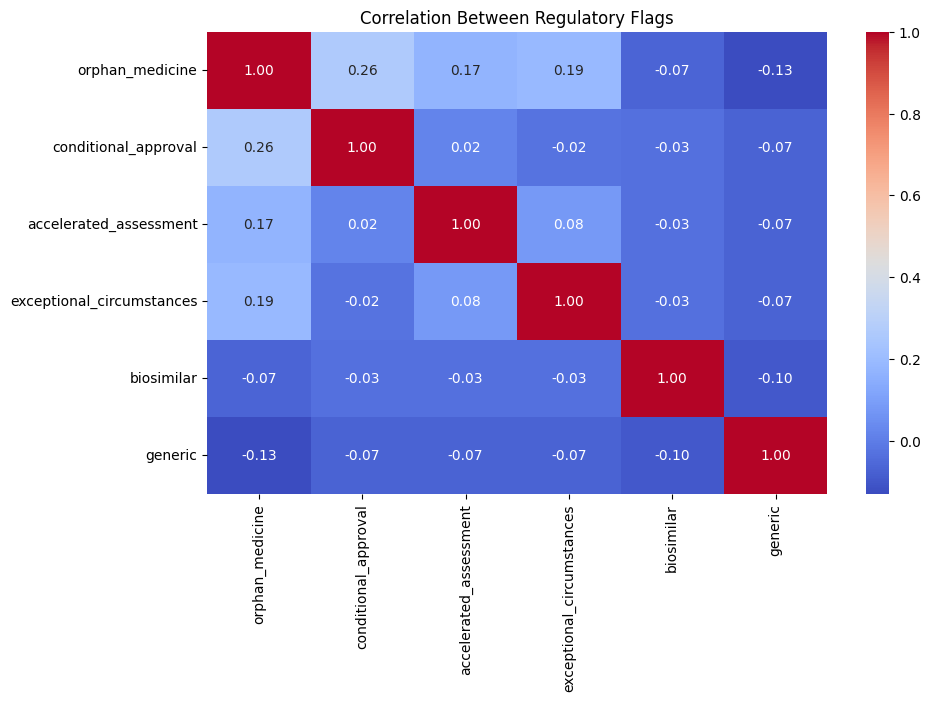

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

flags = ['orphan_medicine', 'conditional_approval', 'accelerated_assessment',
         'exceptional_circumstances', 'biosimilar', 'generic']
flag_counts = drugs[flags].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
correlation_matrix = drugs[flags].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Regulatory Flags')

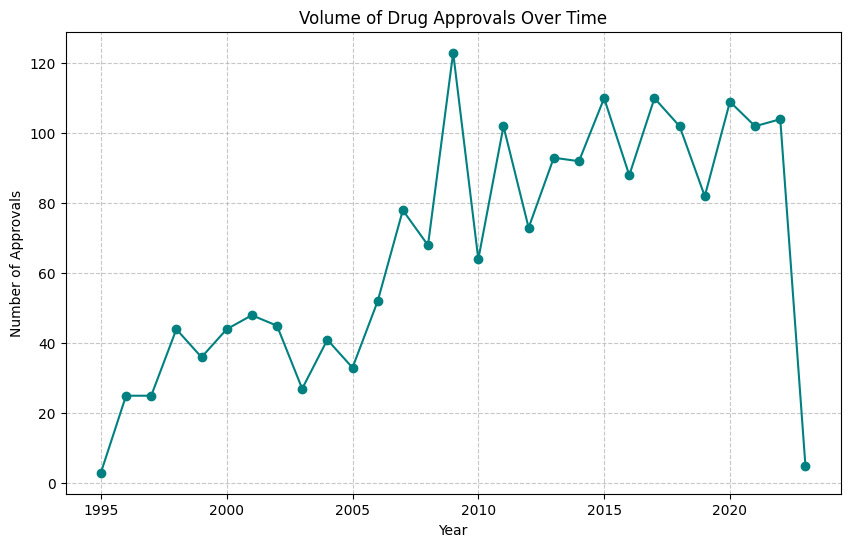

In [5]:
date_cols = ['marketing_authorisation_date', 'decision_date', 'first_published']
for col in date_cols:
    drugs[col] = pd.to_datetime(drugs[col], errors='coerce', utc=True)

drugs['approval_year'] = drugs['marketing_authorisation_date'].dt.year

plt.figure(figsize=(10, 6))
drugs['approval_year'].value_counts().sort_index().plot(kind='line', marker='o', color='teal')
plt.title('Volume of Drug Approvals Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Approvals')
plt.grid(True, linestyle='--', alpha=0.7)

In [6]:
drugs['marketing_authorisation_date'].head(10)

,marketing_authorisation_date
0,2012-10-25 00:00:00+00:00
1,2018-07-26 00:00:00+00:00
2,2022-12-16 00:00:00+00:00
3,2021-11-12 00:00:00+00:00
4,2015-01-14 00:00:00+00:00
5,2012-02-16 00:00:00+00:00
6,2021-11-15 00:00:00+00:00
7,2010-07-27 00:00:00+00:00
8,2007-06-29 00:00:00+00:00
9,2015-07-28 00:00:00+00:00


Text(0.5, 1.0, 'Distribution of Drug Categories')

<Figure size 500x300 with 0 Axes>

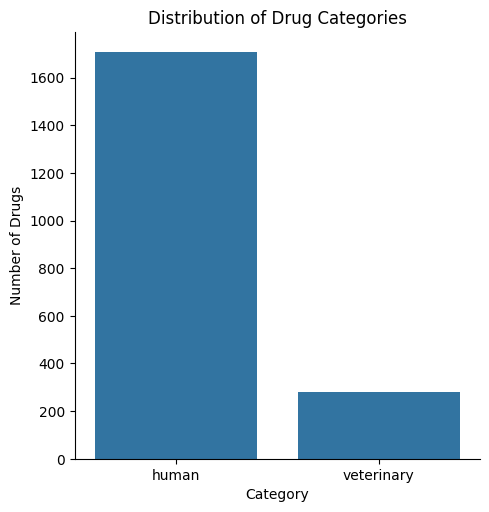

In [7]:
# 1.2 Question 4 (for use in proposal)
categories = drugs['category'].value_counts()
plt.figure(figsize=(5, 3))
sns.catplot(categories, kind = 'bar')
plt.xlabel('Category')
plt.ylabel('Number of Drugs')
plt.title('Distribution of Drug Categories')

Companies in both sectors: 3
Active Substances in both sectors: 7
Example crossovers: ['pregabalin', 'telmisartan', 'dexmedetomidine hydrochloride', 'dibotermin alfa', 'masitinib mesilate']


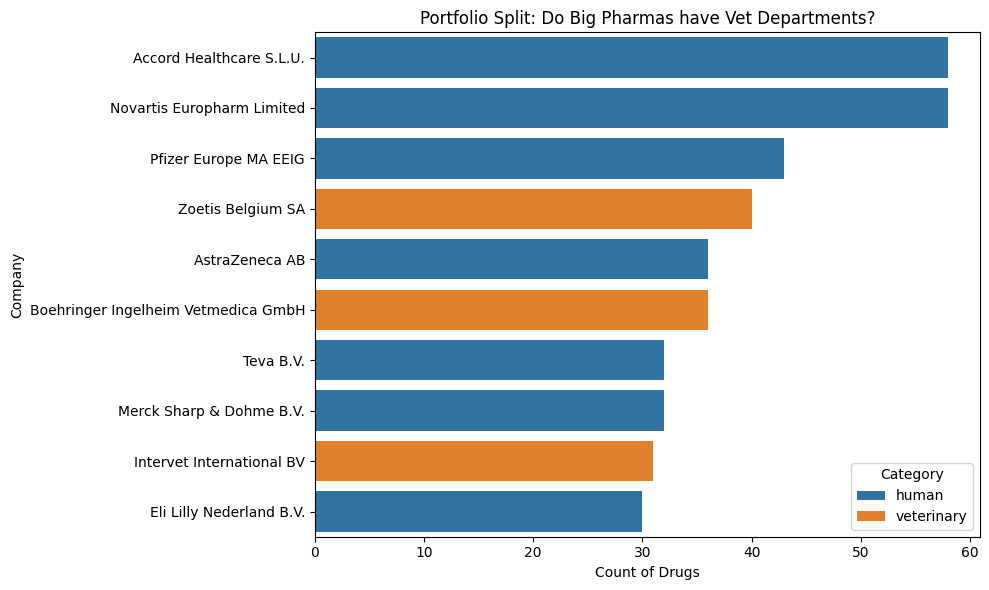

In [8]:
# 1.2 Question 4 (for use)
top_holders = drugs['marketing_authorisation_holder_company_name'].value_counts().head(10).index
filtered_drugs = drugs[drugs['marketing_authorisation_holder_company_name'].isin(top_holders)]

plt.figure(figsize=(10, 6))
sns.countplot(y='marketing_authorisation_holder_company_name',
              data=filtered_drugs,
              hue='category',
              order=top_holders
)
plt.title('Portfolio Split: Do Big Pharmas have Vet Departments?')
plt.xlabel('Count of Drugs')
plt.ylabel('Company')
plt.legend(title='Category', loc='lower right')
plt.tight_layout()
plt.savefig('company_portfolio_split.png')